# Credit Card Fraud Detection
Team Members: Joshua Hanscom,  Andrew Rivera and Abigail Diaz

Course: CS 4662 - Advanced Machine Learning and Deep Learning

Instructor: Professor Mohammad Pourhomayoun

Date: March 2026

## 1. Introduction
Credit card fraud is a significant problem in the financial sector, costing billions of dollars annually. Detecting fraudulent transactions in real-time is challenging due to the massive volume of legitimate transactions compared to a very small number of fraudulent ones. In this project, we analyze a dataset of European credit card transactions to build and evaluate models capable of identifying fraud.

Using this dataset, we pursue three main objectives:

- Classification: Apply machine learning models to predict whether a specific transaction is fraudulent or legitimate.

- Handling Extreme Imbalance: Implement data sampling techniques to address the severe class imbalance inherent in fraud detection data.

- Performance vs. Computation: Evaluate the trade-offs between model accuracy and the computational complexity required to train them on large datasets.

By comparing multiple modeling strategies, we aim to determine which methods deliver the most reliable detection of fraud without flagging too many legitimate transactions as false positives.

# 1.1 Configuration

We define global configuration values used throughout the project, such as random seeds and common parameters.

In [27]:
import os
import pandas as pd
import numpy as np

RANDOM_STATE = 42
TEST_SIZE = 0.2
NUM_FOLDS = 10

# for reproducibility

np.random.seed(RANDOM_STATE)

def save_results(model_name, scores, file_path="results.csv"):
    results = pd.DataFrame({
        "model": [model_name],
        "mean_f1": [scores["test_f1"].mean()],
        "std_f1": [scores["test_f1"].std()],
        "mean_recall": [scores["test_recall"].mean()],
        "std_recall": [scores["test_recall"].std()],
        "mean_auprc": [scores["test_auprc"].mean()],
        "std_auprc": [scores["test_auprc"].std()],
    })

    results.to_csv(
        file_path,
        mode="a",
        header=not os.path.exists(file_path),
        index=False
    )

## 2. Dataset Description
The dataset, sourced from Kaggle (ULB Machine Learning Group), contains credit card transactions made by European cardholders in September 2013. It includes 284,807 transactions over a two-day period.

The dataset is highly imbalanced, with only 492 fraudulent transactions, accounting for just 0.172% of the total data. Due to confidentiality reasons, the original features have been transformed using Principal Component Analysis (PCA).

Features: 28 numerical features (V1 through V28) which are the principal components obtained with PCA.

Un-transformed Features: Time (seconds elapsed between each transaction and the first transaction) and Amount (the transaction value).

Target Variable: Class, a binary variable indicating whether the transaction is fraudulent (1 = yes, 0 = no).

## 3. Data Preprocessing
To prepare the dataset for modeling, we will implement the following pipeline:

- Scaling: While the PCA features (V1-V28) are already scaled, the Time and Amount features are not. We will apply a robust scaling method to the Amount feature to mitigate the influence of extreme transaction outliers.

- Handling Class Imbalance: Because fraudulent transactions are extremely rare, training a model on the raw data will lead to bias. We will utilize sampling techniques (such as random undersampling of the majority class) to create a balanced subset of data for initial model training.

- Splitting the Dataset: We will perform a train-test split using a stratified approach to ensure the original ratio of fraud-to-normal transactions is preserved across both the training and testing sets.

### 3.1 Loading the Dataset

We begin by downloading and loading the credit card fraud dataset from [kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download).

We can utilize the provided code template to assist in the import.

In [1]:
import kagglehub
import pandas as pd
import os

# download dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

# load the csv file
csv_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_path)

# preview data
df.head()

Path to dataset files: C:\Users\joshu\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 3.2 Defining Features and Labels

We separate the dataset into a feature matrix (`X`) and target vector (`y`).

We define our feature columns as all features **EXCEPT** our target `Class`. We can then easily use that definition to declare `X`, our feature matrix.

From there, we can define `y` as our label vector using `class`.

In [18]:
#define feature matrix using defined input columns
# define features as all except Class (target)
X = df.drop("Class", axis=1)

X.shape

(284807, 30)

In [12]:
# define label vector
y = df['Class']

y[::50000]

0         0
50000     0
100000    0
150000    0
200000    0
250000    0
Name: Class, dtype: int64

### 3.3 Splitting the Dataset

We split the dataset into training and testing sets using stratification to preserve the original class distribution.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

### 3.4 Class Distribution

We visualize the distribution of fraudulent and non-fraudulent transactions to better understand the class imbalance in the dataset.

Due to the extreme imbalance, where fraudulent transactions represent a very small fraction of the data, we annotate the counts to make the minority class more visible.

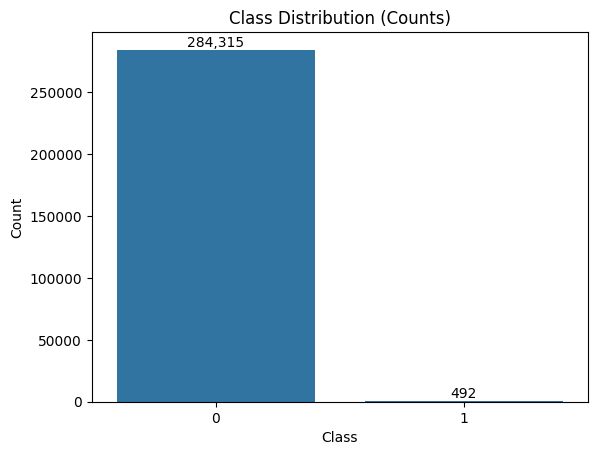

In [23]:
counts = y.value_counts()

ax = sns.barplot(x=counts.index, y=counts.values)

for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.title("Class Distribution (Counts)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## 4. Methods / Models Used
To thoroughly investigate this dataset, we will implement a tiered modeling strategy, starting with baseline classical algorithms and progressing to advanced ensemble and deep learning techniques.

A primary focus across all models will be addressing the extreme class imbalance. Alongside data sampling, we will heavily utilize model weight tuning (e.g., assigning higher class weights/penalties to fraudulent misclassifications) to force the algorithms to prioritize the minority class without needing to alter the underlying data distribution.

### Classical Baselines

- K-Nearest Neighbors (KNN): We will use KNN to establish a fundamental distance-based baseline for performance, allowing us to gauge the baseline complexity of separating the classes.

- Linear Support Vector Machine (SVM): Because the dataset features (V1-V28) have already undergone Principal Component Analysis (PCA), we will test a Linear SVM to determine if the PCA projection created a linearly separable space for fraudulent and normal transactions.

### Non-Linear & Ensemble Models

- Non-Linear SVM: If the classes are not linearly separable, we will apply a Non-Linear SVM using the kernel trick (e.g., Radial Basis Function) to capture complex decision boundaries.

- Random Forest & Gradient Boosted Trees: We will utilize powerful tree-based ensembles. Random Forest (bagging) will help reduce variance, while Gradient Boosting (boosting) will actively correct misclassifications. These models are highly resilient to imbalanced data and will serve as our primary classical classifiers.

### Deep Learning

- Artificial Neural Networks (ANN): To capture the most complex, underlying representations within the PCA features, we will design and train a multi-layer Artificial Neural Network. The network will be trained using backpropagation, with a focus on optimizing hidden layer architectures and activation functions. To prevent the network from simply predicting the majority "normal" class, we will implement custom loss functions and utilize weighted classes during the training phase.

### Cross-Validation & Hyperparameter Tuning Strategy

To ensure our models generalize to unseen data rather than memorizing the training set, rigorous cross-validation is mandatory across all tiers.

- Stratified K-Fold Cross-Validation: Because the dataset contains only 0.172% fraudulent transactions, a standard random split would likely result in validation folds with zero fraud cases. We will strictly use Stratified K-Fold to guarantee that the exact ratio of fraud-to-normal transactions is preserved perfectly across every training and validation split.


- Efficient Tuning: For computationally heavy models like the Non-Linear SVM and the ANN, we will pair our cross-validation with randomized search techniques on our sampled subsets to find optimal parameters without exceeding processing limits.

### 4.1 Logistic Regression

We begin with Logistic Regression as a baseline model. To prevent data leakage and ensure proper evaluation, we use a pipeline that includes feature scaling and model training. Performance is evaluated using cross-validation.

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

scoring = {
    "f1": "f1",
    "recall": "recall",
    "auprc": "average_precision"
}

scores_lr = cross_validate(
    pipeline_lr,
    X_train,
    y_train,
    cv=NUM_FOLDS,
    scoring=scoring
)

print("Mean F1:", scores_lr["test_f1"].mean())
print("Mean Recall:", scores_lr["test_recall"].mean())
print("Mean AUPRC:", scores_lr["test_auprc"].mean())

save_results("Logistic Regression", scores_lr)

Mean F1: 0.7362314609436209
Mean Recall: 0.6346153846153847
Mean AUPRC: 0.7625674681864939


### 4.2 KNN (K-Nearest Neighbors) Classifier

We implement a K-Nearest Neighbors (KNN) classifier as another baseline model. KNN classifies a data point based on the majority label of its nearest neighbors in the feature space.

Since KNN is sensitive to feature scaling, we incorporate standardization into a pipeline to ensure all features contribute equally to distance calculations. This prevents features with larger magnitudes from dominating the model.

To determine the optimal number of neighbors (k), we perform hyperparameter tuning using GridSearchCV. We evaluate multiple values of k and select the one that maximizes the F1 score using cross-validation.

After identifying the best k, we re-evaluate the model using cross-validation with multiple metrics, including F1 score, recall, and AUPRC, to ensure a fair comparison with other models.

While KNN can be effective in capturing local patterns in the data, it may struggle with large datasets and highly imbalanced classes. Therefore, it is included primarily as a baseline for comparison against more advanced models.

In [38]:
from sklearn.neighbors import KNeighborsClassifier

pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(weights="distance"))
])

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 11, 15]
}


grid_knn = GridSearchCV(
    pipeline_knn,
    param_grid_knn,
    cv=NUM_FOLDS,
    scoring="f1",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print("Best k:", grid_knn.best_params_)
print("Best score:", grid_knn.best_score_)

Best k: {'model__n_neighbors': 3}
Best score: 0.8479538534083704


In [40]:
best_knn = grid_knn.best_estimator_

scores_knn = cross_validate(
    best_knn,
    X_train,
    y_train,
    cv=NUM_FOLDS,
    scoring={
        "f1": "f1",
        "recall": "recall",
        "auprc": "average_precision"
    }
)

print("Mean F1:", scores_knn["test_f1"].mean())
print("Mean Recall:", scores_knn["test_recall"].mean())
print("Mean AUPRC:", scores_knn["test_auprc"].mean())

save_results("KNN", scores_knn)

Mean F1: 0.8479538534083704
Mean Recall: 0.7738461538461537
Mean AUPRC: 0.8024839252013274


## 5. Results and Evaluation
Because 99.8% of the data belongs to the "Not Fraud" class, standard accuracy is not a valid metric for this project. Instead, our evaluation will rely on:

- AUPRC (Area Under the Precision-Recall Curve): The primary metric for highly imbalanced data.

- Recall (Sensitivity): To measure our ability to catch as many actual frauds as possible.

- F1-Score: To find the balance between precision and recall.

(results are pending...)



## 6. Discussion
Once models have been trained and evaluated, this section will discuss:

- Which models performed best at detecting fraud and minimizing false positives.

- The impact of data scaling and undersampling on model performance.

- The computational challenges faced when running distance-based algorithms on large datasets.

- Insights gained from the LLM-generated fraud explanations.




## 7. Conclusion
(To be completed: Summarize findings and possible future improvements for a production environment.)


References
Credit Card Fraud Detection Dataset, Kaggle (MLG-ULB): https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data